In [8]:
# import sys
# !{sys.executable} -m pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 10.2 MB/s eta 0:00:00a 0:00:01
Using cached tzdata-2026.2-py2.py3-none-any.whl (349 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [seaborn]m3/4 [seaborn]

[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
import shutil
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout, Conv2D, MaxPool2D, Input
from skimage.io import imread, imshow
from tensorflow.keras.preprocessing.image import ImageDataGenerator


I0000 00:00:1781207536.634021   45050 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781207536.636621   45050 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781207537.516955   45050 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781207544.158914   45050 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [15]:
train_dir = "/home/meme/Documentos/Algoritmos/Fundamentos_MachineLearning/datos/kagglecatsanddogs_5340/PetImages"
d = {"dogs": 0, "cats": 1}
for dir in os.listdir(train_dir):
    path = os.path.join(train_dir, dir)
    d[dir] = len(os.listdir(path))
print(d)

{'dogs': 0, 'cats': 1, 'Cat': 12501, 'Dog': 12501}


/tmp/ipykernel_84363/2591956987.py:1: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(imread("/home/meme/Documentos/Algoritmos/Fundamentos_MachineLearning/datos/kagglecatsanddogs_5340/PetImages/Cat/1000.jpg"))


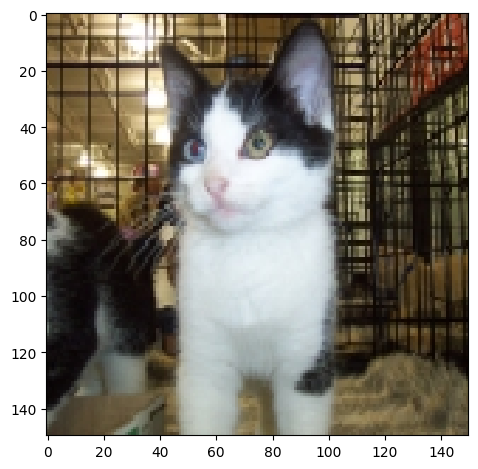

In [16]:
imshow(imread("/home/meme/Documentos/Algoritmos/Fundamentos_MachineLearning/datos/kagglecatsanddogs_5340/PetImages/Cat/1000.jpg"))

/tmp/ipykernel_84363/898593285.py:1: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(imread("/home/meme/Documentos/Algoritmos/Fundamentos_MachineLearning/datos/kagglecatsanddogs_5340/PetImages/Cat/1020.jpg"))


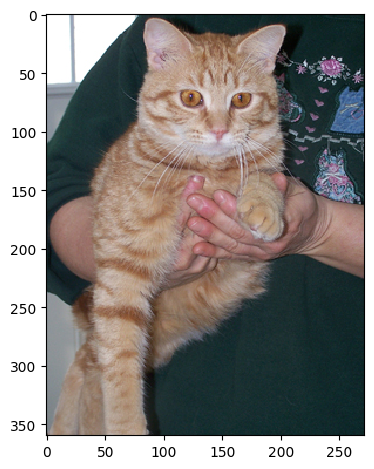

In [17]:
imshow(imread("/home/meme/Documentos/Algoritmos/Fundamentos_MachineLearning/datos/kagglecatsanddogs_5340/PetImages/Cat/1020.jpg"))

/tmp/ipykernel_84363/1123294375.py:1: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(imread("/home/meme/Documentos/Algoritmos/Fundamentos_MachineLearning/datos/kagglecatsanddogs_5340/PetImages/Dog/1000.jpg"))


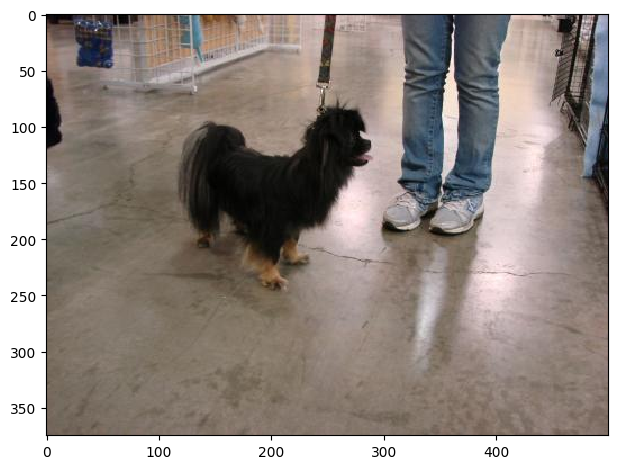

In [18]:
imshow(imread("/home/meme/Documentos/Algoritmos/Fundamentos_MachineLearning/datos/kagglecatsanddogs_5340/PetImages/Dog/1000.jpg"))

In [ ]:
# es importante tener el train_dir para que cuando se quiera ejecutar solo esta linea no me lance el error
ROOT_DIR = "/home/meme/Documentos/Algoritmos/Fundamentos_MachineLearning/datos/cats_dogs"
train_dir = "/home/meme/Documentos/Algoritmos/Fundamentos_MachineLearning/datos/kagglecatsanddogs_5340/PetImages"

# se crea la estructura principal
for carpeta in ['train', 'test', 'val']:
    os.makedirs(os.path.join(ROOT_DIR, carpeta), exist_ok=True)

# se crean subcarpetas Cat y Dog
for clase in os.listdir(train_dir):
    for carpeta in ['train', 'test', 'val']:
        os.makedirs(
            os.path.join(ROOT_DIR, carpeta, clase),
            exist_ok=True
        )

# es importante no hacer os.remove(...) porque se eliminarían los archivos originales, y rompe el dataset original, como alternativa se puede usar shutil.copyfile(...) para copiar los archivos a las nuevas carpetas, y así mantener el dataset original intacto

In [ ]:
# se comprueba que los datos siguen intactos
for clase in os.listdir(train_dir):
    print(clase)

for clase in os.listdir(train_dir):
    print(clase, len(os.listdir(os.path.join(train_dir, clase))))

Cat
Dog
Cat 12501
Dog 12501


In [ ]:
for dir in os.listdir(train_dir):
    de = os.path.join(ROOT_DIR, 'val', dir)
    os.mkdir(de)

    for img in np.random.choice(os.listdir(os.path.join(train_dir, dir)), int(len(os.listdir(os.path.join(train_dir, dir))) * 0.5), replace=False):
        org = os.path.join(train_dir, dir, img)
        dest = os.path.join(de, img)
        shutil.copyfile(org, dest)
        os.remove(org)

In [ ]:
for dir in os.listdir(train_dir):
    de = os.path.join(ROOT_DIR, 'test', dir)
    os.mkdir(de)

    for img in np.random.choice(os.listdir(os.path.join(train_dir, dir)), int(len(os.listdir(os.path.join(train_dir, dir)))), replace=True):
        org = os.path.join(train_dir, dir, img)
        dest = os.path.join(de, img)
        shutil.copyfile(org, dest)
        os.remove(org)

In [ ]:
traindatagenerator = ImageDataGenerator(rescale=1.0/255, rotation_range=0.3, zoom_range=0.2, horizontal_flip=True, vertical_flip=True)
train_data = traindatagenerator.flow_from_directory(directory = '')